In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
import time


def plot_history(history, title="Entrenamiento"):
    plt.figure(figsize=(12, 4))

    # Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(history.history["accuracy"], label="train accuracy")
    plt.plot(history.history["val_accuracy"], label="val accuracy")
    plt.title(title + " - Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()

    # Loss
    plt.subplot(1, 2, 2)
    plt.plot(history.history["loss"], label="train loss")
    plt.plot(history.history["val_loss"], label="val loss")
    plt.title(title + " - Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    plt.show()


#**Empezamos aquí**

Carga y preparación de MNIST

In [7]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

x_train = x_train.astype("float32")/255.0
x_test = x_test.astype("float32")/255.0

x_train=x_train.reshape(-1,28,28,1)
x_test=x_test.reshape(-1,28,28,1)

print(x_train.shape)

(60000, 28, 28, 1)


## Modelo denso para MNIST



In [8]:
modelo_denso=models.Sequential([
    layers.Input(shape=(28,28,1)),
    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dense(64, activation="relu"),
    layers.Dense(10, activation="softmax")
])

modelo_denso.compile(
    optimizer="adam",
    loss= "sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

modelo_denso.summary()

### Entrenamiento el modelo

In [11]:
historial =  modelo_denso.fit(
    x_train,
    y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.1
)

Epoch 1/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9885 - loss: 0.0359 - val_accuracy: 0.9910 - val_loss: 0.0361
Epoch 2/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9909 - loss: 0.0289 - val_accuracy: 0.9838 - val_loss: 0.0591
Epoch 3/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9924 - loss: 0.0240 - val_accuracy: 0.9865 - val_loss: 0.0486
Epoch 4/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9928 - loss: 0.0209 - val_accuracy: 0.9857 - val_loss: 0.0491
Epoch 5/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9946 - loss: 0.0164 - val_accuracy: 0.9837 - val_loss: 0.0651


In [12]:
test_loss_denso, test_accuracy_denso = modelo_denso.evaluate(x_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9744 - loss: 0.0927


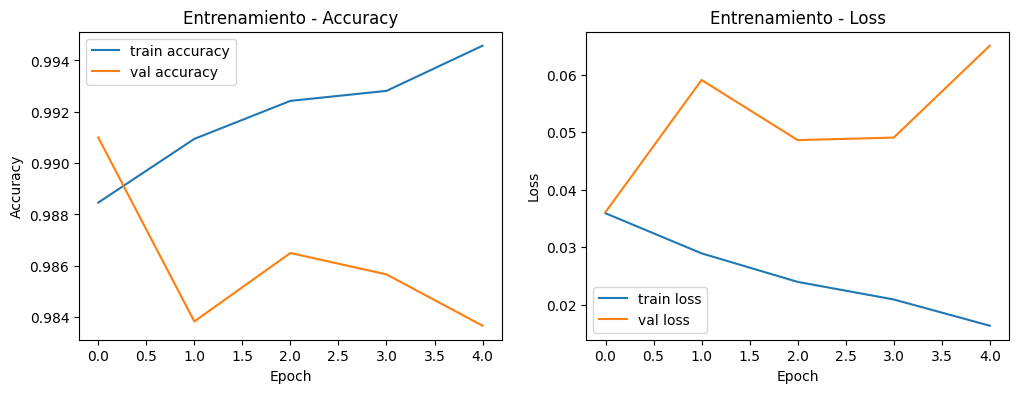

In [13]:
history_denso=historial

plot_history(history_denso)

## Modelo convolucional para MNIST

In [14]:
modelo_cnn=models.Sequential([
    layers.Input(shape=(28,28,1)),
    layers.Conv2D(32, (3,3), activation="relu"),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation="relu"),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dense(10, activation="softmax")
])

modelo_denso.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten (Flatten)                    │ (None, 784)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         100,480 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 10)                  │             650 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 328,160 (1.25 MB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 218,774 (854.59 KB)

### Entrenamiento del modelo CNN



In [15]:
modelo_cnn.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)
history_cnn=modelo_cnn.fit(
    x_train,
    y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.1
)

Epoch 1/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 20s 21ms/step - accuracy: 0.9372 - loss: 0.2053 - val_accuracy: 0.9805 - val_loss: 0.0654
Epoch 2/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 18s 22ms/step - accuracy: 0.9810 - loss: 0.0627 - val_accuracy: 0.9858 - val_loss: 0.0545
Epoch 3/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 18s 21ms/step - accuracy: 0.9873 - loss: 0.0428 - val_accuracy: 0.9865 - val_loss: 0.0398
Epoch 4/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 20s 23ms/step - accuracy: 0.9901 - loss: 0.0322 - val_accuracy: 0.9870 - val_loss: 0.0419
Epoch 5/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 20s 23ms/step - accuracy: 0.9917 - loss: 0.0266 - val_accuracy: 0.9903 - val_loss: 0.0346


313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9918 - loss: 0.0271
Acc: 0.9918000102043152
Loss: 0.02706080861389637


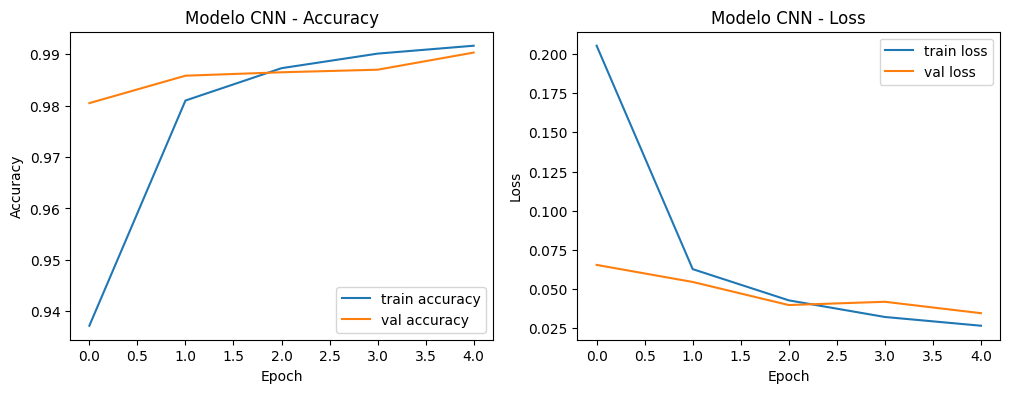

In [17]:
test_loss_cnn, test_acc_cnn= modelo_cnn.evaluate(x_test, y_test)
print("Acc:", test_acc_cnn)
print("Loss:", test_loss_cnn)

plot_history(history_cnn, "Modelo CNN")

## 6. Comparación entre modelo denso y CNN en MNIST

# **CIFAR-10 con red convolucional**

CIFAR-10 es más difícil que MNIST.


In [18]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 24s 0us/step


In [20]:
x_train = x_train.astype("float32")/255
x_test= x_test.astype("float32")/255

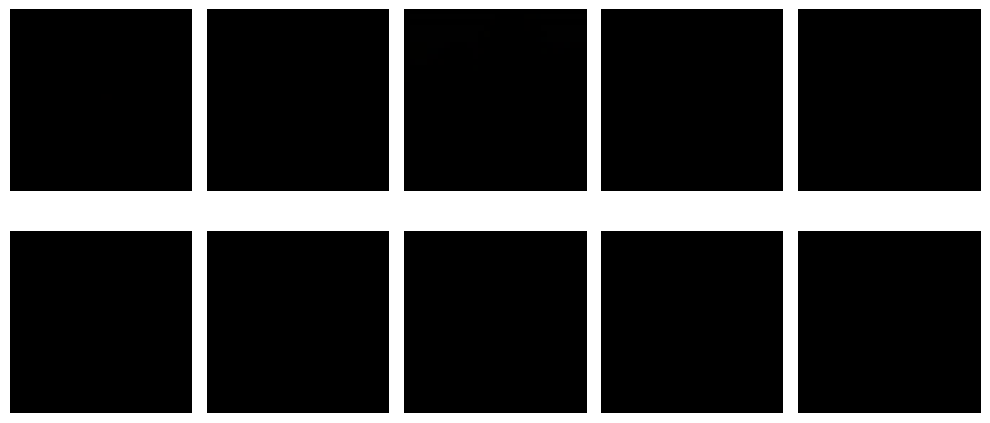

In [22]:
class_names = [
    "avión",
    "coche",
    "pájaro",
    "gato",
    "ciervo",
    "perro",
    "rana",
    "caballo",
    "barco",
    "camión"
]

plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5, i+1)
    plt.imshow(x_train[i])
    plt.axis("off")

plt.tight_layout()
plt.show()

## CNN para CIFAR-10 sin data augmentation

In [23]:
modelo_cifar_cnn=models.Sequential([
    layers.Input(shape=(32,32,3)),
    layers.Conv2D(32,(3,3), activation="relu", padding="same"),
    layers.Conv2D(32,(3,3), activation="relu", padding="same"),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64,(3,3), activation="relu", padding="same"),
    layers.Conv2D(64,(3,3), activation="relu", padding="same"),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(1287, (3,3), activation="relu", padding="same"),
    layers.MaxPooling2D((2,2),),

    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(10, activation="softmax")

])

modelo_cifar_cnn.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [24]:
history_cifar_cnn= modelo_cifar_cnn.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.1
    
)

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 300s 422ms/step - accuracy: 0.0977 - loss: 2.3028 - val_accuracy: 0.0950 - val_loss: 2.3028
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 342s 486ms/step - accuracy: 0.0979 - loss: 2.3027 - val_accuracy: 0.0976 - val_loss: 2.3029
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 205s 291ms/step - accuracy: 0.0994 - loss: 2.3027 - val_accuracy: 0.0958 - val_loss: 2.3029
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 218s 310ms/step - accuracy: 0.0984 - loss: 2.3027 - val_accuracy: 0.0950 - val_loss: 2.3029
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 227s 323ms/step - accuracy: 0.0980 - loss: 2.3027 - val_accuracy: 0.0950 - val_loss: 2.3029
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 230s 327ms/step - accuracy: 0.0960 - loss: 2.3027 - val_accuracy: 0.0958 - val_loss: 2.3029
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 256s 364ms/step - accuracy: 0.0976 - loss: 2.3027 - val_accuracy: 0.0976 - val_loss: 2.3028
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 207s 294ms/step - accuracy: 0.0962 -

### Entrenamiento de la CNN en CIFAR-10

Usamos 10 épocas. CIFAR-10 es más complejo que MNIST, así que suele necesitar más entrenamiento y arquitecturas más potentes.


In [ ]:
test_loss_cifar, test_acc_cifar = history_cifar_cnn.evaluate(x_test, y_test)
print("Loss", test_loss_cifar)
print("Accuracy", test_acc_cifar)

plot_history(history_cifar_cnn, "CNN- CIFAR")

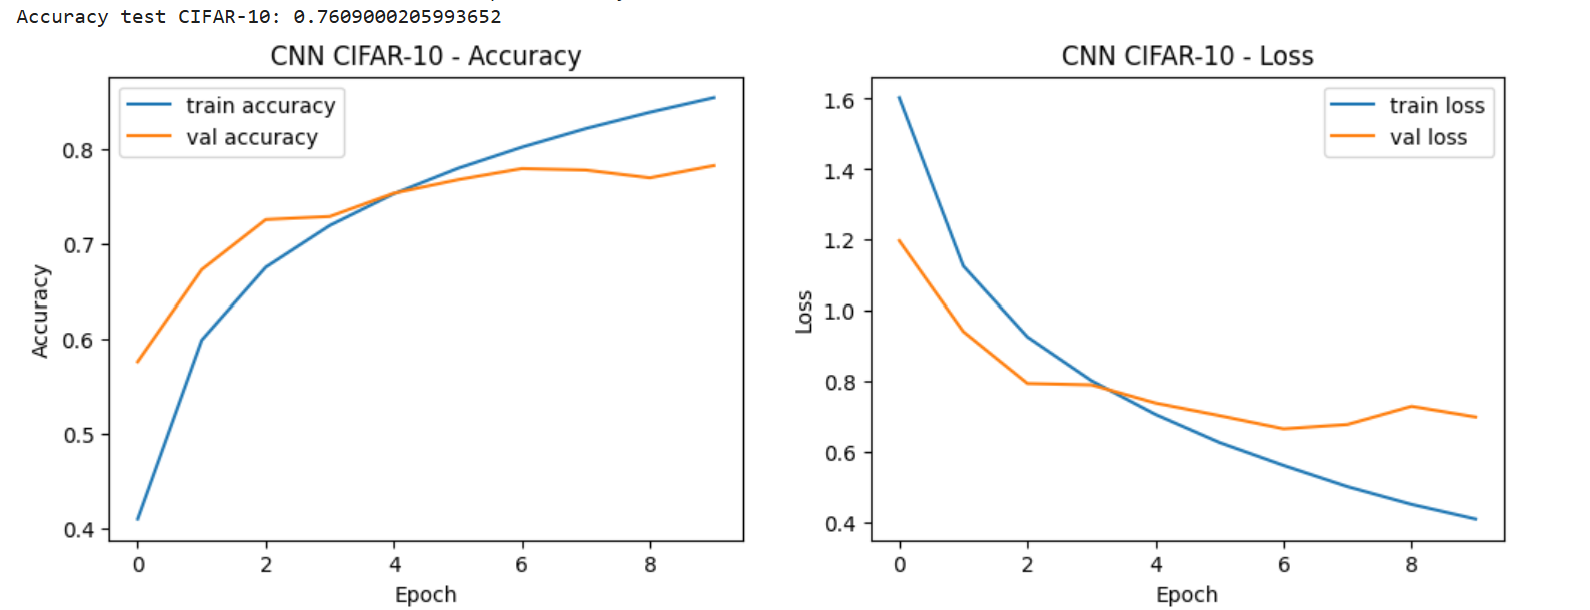

# Data augmentation en CIFAR-10

## Definición del data augmentation
- `RandomFlip("horizontal")`: voltea la imagen horizontalmente.
- `RandomRotation(0.1)`: rota ligeramente.
- `RandomZoom(0.1)`: aplica zoom.
- `RandomTranslation(0.1, 0.1)`: desplaza la imagen.


## Visualización del data augmentation

## CNN con data augmentation, Batch Normalization y Dropout


### Entrenamiento del modelo con data augmentation

## Comparación final en CIFAR-10


# **Arquitectura CNN propia**

**Crear filtros manuales**

Convolución 2D manual

Activación ReLU manual

Resultado